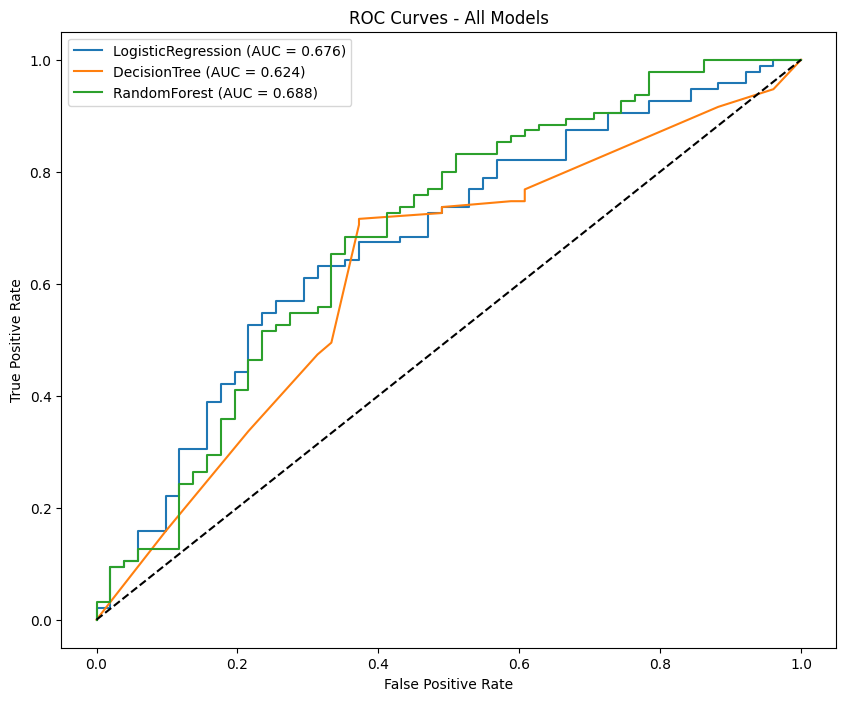


Summary Table of All Models:


,Model,Accuracy,Precision,Recall,F1,AUC
0,LogisticRegression,0.650685,0.789474,0.631579,0.701754,0.676367
1,DecisionTree,0.684932,0.781609,0.715789,0.747253,0.624252
2,RandomForest,0.657534,0.764706,0.684211,0.722222,0.687513


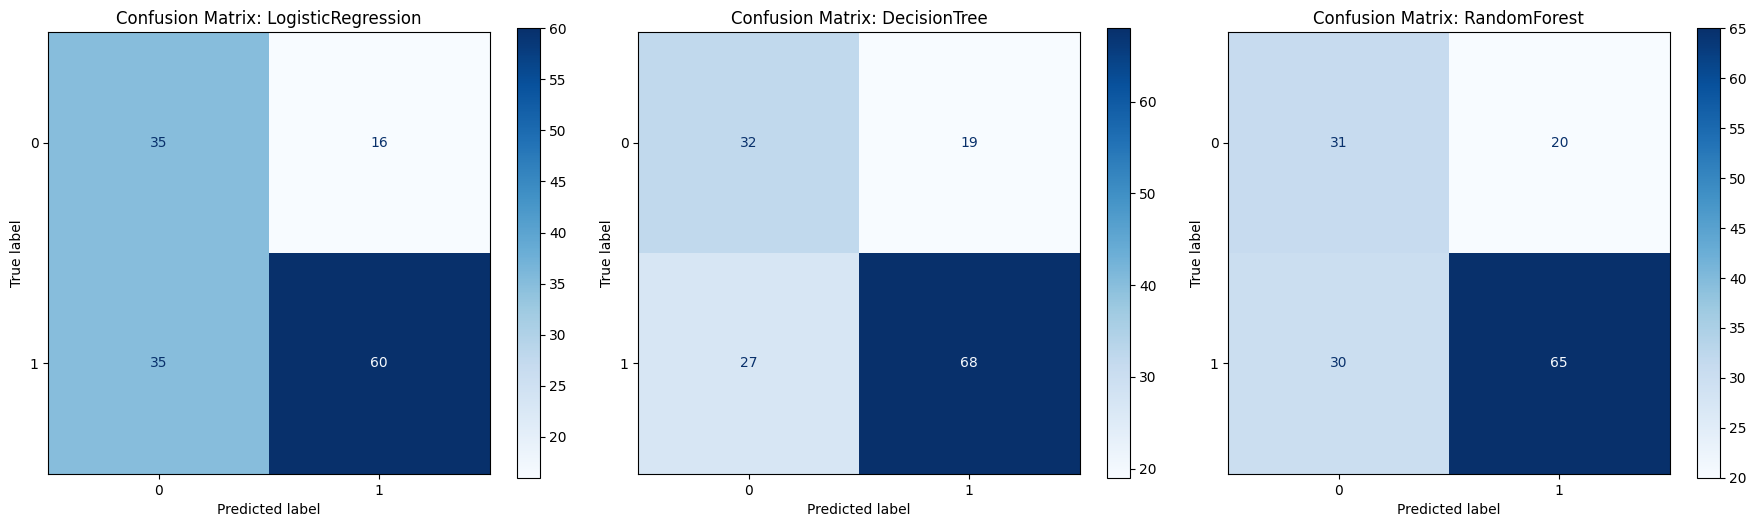

In [ ]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay

# --- CONFIG ---
TW = 10
PING_PONG_TIME_WINDOW = 5
RANDOM_STATE = 42

# --- DATA LOADING ---
df = pd.read_csv('/content/handover_log (2).csv')
ue_id_col = 'UE_ID'
time_col = 'Timestamp(s)'
serving_cell_col = 'Serving_gNB'
target_cell_col = 'Target_gNB'
rsrp_col = 'RSRP(dBm)'
sinr_col = 'Serving_SINR(dB)'
df = df.sort_values(by=[ue_id_col, time_col]).reset_index(drop=True)

# --- FEATURE ENGINEERING ---
def generate_pp_data(group):
    results = []
    group = group.sort_values(time_col)
    for i in range(len(group)):
        curr_row = group.iloc[i]
        curr_t = curr_row[time_col]
        win = group[(group[time_col] <= curr_t) & (group[time_col] > curr_t - TW)]
        n_ho = len(win)
        hos = win[serving_cell_col].tolist()
        f_ho = n_ho / TW
        sigma2_rsrp = win[rsrp_col].var() if n_ho > 1 else 0
        rev_count = 0
        osc_sum = 0
        if n_ho >= 3:
            for k in range(2, n_ho):
                if hos[k] == hos[k-2]:
                    rev_count += 1
                    osc_sum += 1
        r_rev = rev_count / n_ho if n_ho > 0 else 0
        osc_score = osc_sum / max(n_ho - 1, 1)
        dwell = TW / max(n_ho, 1)
        is_pp = 0
        future_win = group[(group[time_col] > curr_t) & (group[time_col] <= curr_t + PING_PONG_TIME_WINDOW)]
        for _, f_row in future_win.iterrows():
            if f_row[serving_cell_col] == curr_row[target_cell_col] and f_row[target_cell_col] == curr_row[serving_cell_col]:
                is_pp = 1
                break
        results.append({'f_HO': f_ho, 'sigma2_RSRP': sigma2_rsrp, 'R_rev': r_rev, 'Oscillation': osc_score, 'Dwell': dwell, 'SINR': curr_row[sinr_col], 'RSRP': curr_row[rsrp_col], 'Target': is_pp})
    return pd.DataFrame(results)

ml_df = df.groupby(ue_id_col, group_keys=False).apply(generate_pp_data, include_groups=False)
ml_df.fillna(0, inplace=True)

# --- SPLITTING & PREPROCESSING ---
X = ml_df.drop('Target', axis=1)
y = ml_df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- GRID SEARCH ---
models_config = {
    'LogisticRegression': {'model': LogisticRegression(solver='liblinear', random_state=RANDOM_STATE), 'params': {'C': [0.1, 1, 10], 'penalty': ['l1', 'l2'], 'class_weight': [None, 'balanced']}, 'use_scale': True},
    'DecisionTree': {'model': DecisionTreeClassifier(random_state=RANDOM_STATE), 'params': {'max_depth': [5, 10, None], 'class_weight': [None, 'balanced']}, 'use_scale': False},
    'RandomForest': {'model': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), 'params': {'n_estimators': [100, 200], 'max_depth': [5, 10], 'class_weight': [None, 'balanced']}, 'use_scale': False}
}
best_models = {}
for name, cfg in models_config.items():
    xt = X_train_scaled if cfg['use_scale'] else X_train
    gs = GridSearchCV(cfg['model'], cfg['params'], cv=5, scoring='roc_auc')
    gs.fit(xt, y_train)
    best_models[name] = gs.best_estimator_

# --- EVALUATION METRICS & ROC ---
results_metrics = []
plt.figure(figsize=(10, 8))
for name, model in best_models.items():
    xt_eval = X_test_scaled if models_config[name]['use_scale'] else X_test
    y_pred = model.predict(xt_eval)
    y_prob = model.predict_proba(xt_eval)[:, 1]
    res = {'Model': name, 'Accuracy': accuracy_score(y_test, y_pred), 'Precision': precision_score(y_test, y_pred), 'Recall': recall_score(y_test, y_pred), 'F1': f1_score(y_test, y_pred), 'AUC': roc_auc_score(y_test, y_prob)}
    results_metrics.append(res)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['AUC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curves - All Models'); plt.legend(); plt.show()

# --- METRICS TABLE ---
metrics_df = pd.DataFrame(results_metrics)
print("\nSummary Table of All Models:")
display(metrics_df)

# --- CONFUSION MATRICES ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, model) in enumerate(best_models.items()):
    xt_eval = X_test_scaled if models_config[name]['use_scale'] else X_test
    ConfusionMatrixDisplay.from_estimator(model, xt_eval, y_test, ax=axes[i], cmap='Blues')
    axes[i].set_title(f'Confusion Matrix: {name}')
plt.tight_layout(); plt.show()

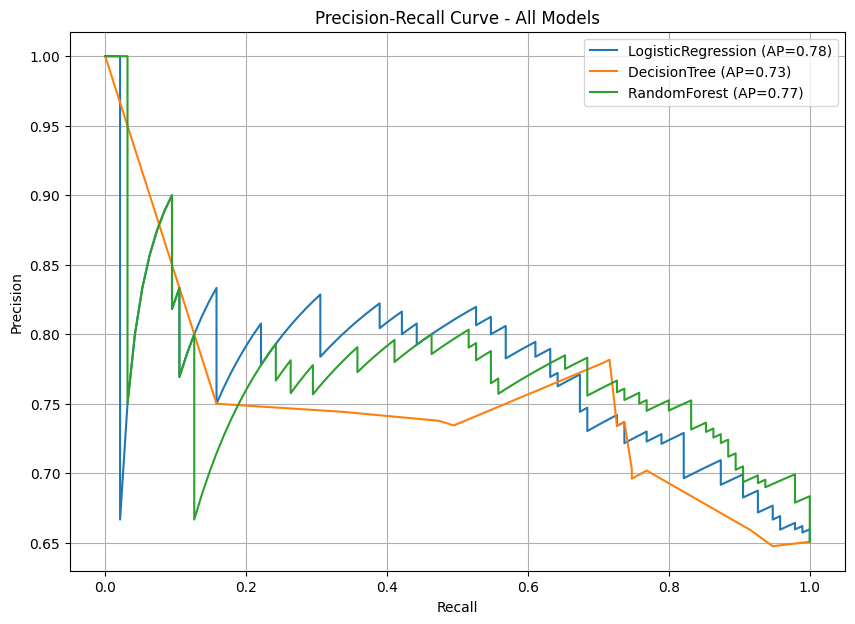

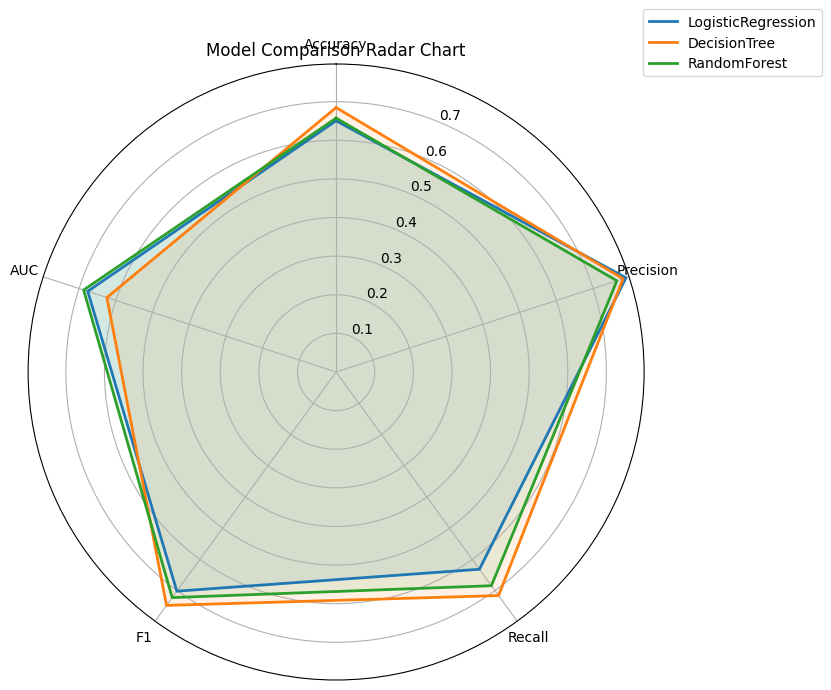


--- EXPORT COMPLETE ---
Files saved in 'inference_pack/':
- dt_model.pkl
- rf_model.pkl
- logistic_model.pkl
- scaler.pkl (Use this first to transform raw engineered features)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 1. PRECISION-RECALL CURVES ---
plt.figure(figsize=(10, 7))
for name, model in best_models.items():
    xt_eval = X_test_scaled if models_config[name]['use_scale'] else X_test
    probs = model.predict_proba(xt_eval)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - All Models")
plt.legend()
plt.grid(True)
plt.show()

# --- 2. RADAR CHART (Comparison of Metrics) ---
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
num_vars = len(metrics_to_plot)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for res in results_metrics:
    values = [res[m] for m in metrics_to_plot]
    values += values[:1] # Close the loop
    ax.plot(angles, values, linewidth=2, label=res['Model'])
    ax.fill(angles, values, alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), metrics_to_plot)
plt.title("Model Comparison Radar Chart")
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

# --- 3. EXPORT MODELS AND SCALER ---
os.makedirs('inference_pack', exist_ok=True)

# Map internal names to requested filenames
export_map = {
    'DecisionTree': 'dt_model.pkl',
    'RandomForest': 'rf_model.pkl',
    'LogisticRegression': 'logistic_model.pkl'
}

for internal_name, filename in export_map.items():
    with open(f'inference_pack/{filename}', 'wb') as f:
        pickle.dump(best_models[internal_name], f)

# Save the scaler for the feature pipeline
with open('inference_pack/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\n--- EXPORT COMPLETE ---")
print("Files saved in 'inference_pack/':")
print("- dt_model.pkl")
print("- rf_model.pkl")
print("- logistic_model.pkl")
print("- scaler.pkl (Use this first to transform raw engineered features)")